In [ ]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from typing import TypedDict, Literal
import tabula
import os

from langchain_ollama import OllamaEmbeddings
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document

In [82]:
load_dotenv()

True

In [ ]:
# Loading the Grobal variables
groq_api_keys=os.getenv("Groq_API_Key")
groq_temperature=os.getenv("Groq_Temperature")
groq_model_name=os.getenv("Groq_Model_Name")

ollama_embedding_model_name=os.getenv("Ollama_Embedding_Model_Name")
ollama_embedding_model_temperature=os.getenv("Ollama_Embedding_Model_Temperature")

In [84]:
# This is defination of the text.
class KnowledgeIntelligenceState(TypedDict):
    pdf_file_path:str
    query:str 
    loader:any
    splitter:any
    embedding:any
    retriever_data:any
    prompt:any
    prompt2:any
    llm:any
    answer:any

    tabular_data:any
    tabular_to_text_conversion:any
    tabular_splitted_data:any
    tabular_retriever:any
    tabular_prompt:any

In [85]:
# Texual loader node is here
def document_loading(state:KnowledgeIntelligenceState):
    loader=PyPDFLoader(file_path=state["pdf_file_path"])
    loaded_data=loader.load()
    return {
        "loader": loaded_data
    }

In [86]:
# Tabular loader node is here
def Tabular_Document_Loader(state:KnowledgeIntelligenceState):
    tfs = tabula.read_pdf(
        state["pdf_file_path"],
        pages="all"
    )
    if tfs:
        return {'tabular_data':tfs[0]}
    else:
        return {'tabular_data':"none"}

In [87]:
# Table to text conversion node
def Tabular_to_text_conversion(state:KnowledgeIntelligenceState):
    state['prompt2']=PromptTemplate(template="""
        You are an expert in converting noisy and unstructured tabular data into  clear, well-written textual format.

        You will be provided with data that originally comes from a table but may be poorly formatted or flattened. Your task is to:

            1) Identify the column names and row relationships implicitly present in the data.
            2) Preserve the semantic relationships between columns and rows.
            3) Convert each row into clear, complete, and grammatically correct 
            4) sentences using the column context.
            5) Avoid losing any information present in the table.
            Do not hallucinate or add new data.

        The final output should be a coherent textual explanation, suitable for documentation or downstream RAG usage.
        This is the tabular data:
        {tabular_data}
    """,input_variables=['tabular_data'])
    state['llm'] = ChatGroq(model=groq_model_name,temperature=groq_temperature)
    parser = StrOutputParser()
    chain = state['prompt2'] | state['llm'] | parser
    data=chain.invoke({
        "tabular_data": state["tabular_data"]
    })
    return {'tabular_to_text_conversion':data}

In [88]:
# splitter node is here
def text_splitting(state:KnowledgeIntelligenceState):
    splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
    splitted_text=splitter.split_documents(state["loader"])
    return {
        "splitter": splitted_text
    }

In [89]:
# Table splitter node is here
def table_splitting(state:KnowledgeIntelligenceState):
    splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
    docs = [
        Document(
            page_content=state["tabular_to_text_conversion"],
            metadata={"type": "table"}
        )
    ]

    splitted_text = splitter.split_documents(docs)
    
    return {
        "tabular_splitted_data": splitted_text
    }

In [90]:
# embedding node is here
def doc_embedding(state:KnowledgeIntelligenceState):
    emb=OllamaEmbeddings(model=ollama_embedding_model_name)
    return {"embedding":emb}

In [91]:
# vectorstore node is here
def vectorstore_node(state:KnowledgeIntelligenceState):
    db=FAISS.from_documents(
        documents=state['splitter'],
        embedding=state["embedding"]
    )
    retriever=db.as_retriever(search_type="mmr",search_kwargs={"k": 4})
    retrieved_context = retriever.invoke(state["query"])

    return {"retriever_data":retrieved_context}


In [92]:
# Tabular retriever node is here
def Tabular_vectorstore_node(state:KnowledgeIntelligenceState):
    db=FAISS.from_documents(
        documents=state['tabular_splitted_data'],
        embedding=state["embedding"]
    )
    retriever=db.as_retriever(search_type="mmr",search_kwargs={"k": 4})
    retrieved_context = retriever.invoke(state["query"])

    return {"tabular_retriever":retrieved_context}

In [93]:
def LLMGeneration(state:KnowledgeIntelligenceState):
    state['llm'] = ChatGroq(model=groq_model_name,temperature=groq_temperature)
    state['prompt'] = PromptTemplate(template="""
                        You are a helpful assistant.
                        Answer the question ONLY using the provided context.
                        Context:
                        {context}
                        {context2}
                        Question:
                        {question}
                    """,input_variables=['question','context','context2']
                    )       

    parser = StrOutputParser()
    chain = state['prompt'] | state['llm'] | parser
    context_text = "\n\n".join(doc.page_content for doc in state["retriever_data"])
    context_text2 = "\n\n".join(doc.page_content for doc in state["tabular_retriever"])

    answer = chain.invoke({
        "context": context_text,
        "context2":context_text2,
        "question": state["query"]
    })

    return {
        "answer": answer
    }

In [94]:
graph = StateGraph(KnowledgeIntelligenceState)

graph.add_node("load", document_loading)
graph.add_node("table_load",Tabular_Document_Loader)
graph.add_node("table_to_text",Tabular_to_text_conversion)
graph.add_node("split", text_splitting)
graph.add_node("table_split",table_splitting)
graph.add_node("emb", doc_embedding)
graph.add_node("vs",vectorstore_node)
graph.add_node("table_vs",Tabular_vectorstore_node)
graph.add_node("LLMGenerate",LLMGeneration)

In [95]:
graph.add_edge(START,"load")
graph.add_edge("load","split")
graph.add_edge("split","emb")
graph.add_edge("emb","vs")
graph.add_edge("vs","LLMGenerate")

graph.add_edge(START,"table_load")
graph.add_edge("table_load","table_to_text")
graph.add_edge("table_to_text","table_split")
graph.add_edge("table_split","emb")
graph.add_edge("emb","table_vs")
graph.add_edge("table_vs","LLMGenerate")

graph.add_edge("LLMGenerate", END)

In [96]:
workflow = graph.compile()

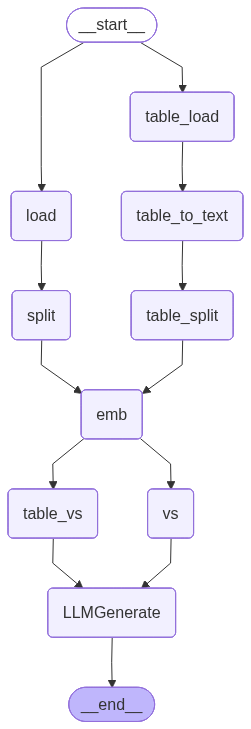

In [97]:
workflow

In [98]:
initial_data={
    "pdf_file_path": "../Input-Document/plain_text.pdf",
    "query": "What are the ethical consideration during AI document generation?"
}

result = workflow.invoke(initial_data)

In [99]:
#Whole state printing
result

{'pdf_file_path': '../Input-Document/plain_text.pdf',
 'query': 'What are the ethical consideration during AI document generation?',
 'loader': [Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-01-28T10:12:58+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-01-28T10:12:58+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../Input-Document/plain_text.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='The Evolution of Artificial Intelligence\nArtificial Intelligence (AI) refers to the ability of machines to perform tasks that typically require\nhuman intelligence, such as learning, reasoning, problem-solving, and language understanding.\nThe concept of AI dates back to the mid-20th century, when researchers first began exploring\nwhether machines could simulate aspects of human cognition. Early AI systems were rule-based\nand relied hea

In [100]:
#main answer printing
print(result['answer'])

The ethical considerations for AI‑generated documents, as highlighted in the passage, include:

- **Data privacy** – protecting any personal or sensitive information used or produced by the system.  
- **Algorithmic bias** – ensuring the model does not reproduce or amplify unfair biases in the content it creates.  
- **Transparency** – making clear how the document was generated and what data or rules were involved.  
- **Accountability** – establishing who is responsible for the output and for any errors or harms it may cause.  
- **Fairness and alignment with human values** – designing the system so the generated text is equitable, respects societal norms, and reflects the values of its intended audience.  
- **Explainability** – providing understandable reasons for the content choices made by the AI.  

Together, these points form the core of responsible AI practices for document generation.
